# Python Electric Vehicle Statistical Analysis Project 

In [1]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Step 2: Load the Excel file
df = pd.read_csv("FEV_Data.csv")
df.head()

,Car full name,Make,Model,Minimal price (gross) [PLN],Engine power [KM],Maximum torque [Nm],Type of brakes,Drive type,Battery capacity [kWh],Range (WLTP) [km],...,Permissable gross weight [kg],Maximum load capacity [kg],Number of seats,Number of doors,Tire size [in],Maximum speed [kph],Boot capacity (VDA) [l],Acceleration 0-100 kph [s],Maximum DC charging power [kW],mean - Energy consumption [kWh/100 km]
0,Audi e-tron 55 quattro,Audi,e-tron 55 quattro,345700,360,664,disc (front + rear),4WD,95.0,438,...,3130.0,640.0,5,5,19,200,660.0,5.7,150,24.45
1,Audi e-tron 50 quattro,Audi,e-tron 50 quattro,308400,313,540,disc (front + rear),4WD,71.0,340,...,3040.0,670.0,5,5,19,190,660.0,6.8,150,23.80
2,Audi e-tron S quattro,Audi,e-tron S quattro,414900,503,973,disc (front + rear),4WD,95.0,364,...,3130.0,565.0,5,5,20,210,660.0,4.5,150,27.55
3,Audi e-tron Sportback 50 quattro,Audi,e-tron Sportback 50 quattro,319700,313,540,disc (front + rear),4WD,71.0,346,...,3040.0,640.0,5,5,19,190,615.0,6.8,150,23.30
4,Audi e-tron Sportback 55 quattro,Audi,e-tron Sportback 55 quattro,357000,360,664,disc (front + rear),4WD,95.0,447,...,3130.0,670.0,5,5,19,200,615.0,5.7,150,23.85


In [3]:
print ("Dataset Length: ", len(df))
print ("Dataset Shape: ", df.shape)

Dataset Length:  53
Dataset Shape:  (53, 25)


In [4]:
df.head(10)

,Car full name,Make,Model,Minimal price (gross) [PLN],Engine power [KM],Maximum torque [Nm],Type of brakes,Drive type,Battery capacity [kWh],Range (WLTP) [km],...,Permissable gross weight [kg],Maximum load capacity [kg],Number of seats,Number of doors,Tire size [in],Maximum speed [kph],Boot capacity (VDA) [l],Acceleration 0-100 kph [s],Maximum DC charging power [kW],mean - Energy consumption [kWh/100 km]
0,Audi e-tron 55 quattro,Audi,e-tron 55 quattro,345700,360,664,disc (front + rear),4WD,95.0,438,...,3130.0,640.0,5,5,19,200,660.0,5.7,150,24.45
1,Audi e-tron 50 quattro,Audi,e-tron 50 quattro,308400,313,540,disc (front + rear),4WD,71.0,340,...,3040.0,670.0,5,5,19,190,660.0,6.8,150,23.80
2,Audi e-tron S quattro,Audi,e-tron S quattro,414900,503,973,disc (front + rear),4WD,95.0,364,...,3130.0,565.0,5,5,20,210,660.0,4.5,150,27.55
3,Audi e-tron Sportback 50 quattro,Audi,e-tron Sportback 50 quattro,319700,313,540,disc (front + rear),4WD,71.0,346,...,3040.0,640.0,5,5,19,190,615.0,6.8,150,23.30
4,Audi e-tron Sportback 55 quattro,Audi,e-tron Sportback 55 quattro,357000,360,664,disc (front + rear),4WD,95.0,447,...,3130.0,670.0,5,5,19,200,615.0,5.7,150,23.85
5,Audi e-tron Sportback S quattro,Audi,e-tron Sportback S quattro,426200,503,973,disc (front + rear),4WD,95.0,369,...,3130.0,565.0,5,5,20,210,615.0,4.5,150,27.20
6,BMW i3,BMW,i3,169700,170,250,disc (front + rear),2WD (rear),42.2,359,...,1730.0,440.0,4,5,19,160,260.0,8.1,50,13.10
7,BMW i3s,BMW,i3s,184200,184,270,disc (front + rear),2WD (rear),42.2,345,...,1730.0,440.0,4,5,20,160,260.0,6.9,50,14.30
8,BMW iX3,BMW,iX3,282900,286,400,disc (front + rear),2WD (rear),80.0,460,...,2725.0,540.0,5,5,19,180,510.0,6.8,150,18.80
9,Citroën ë-C4,Citroën,ë-C4,125000,136,260,disc (front + rear),2WD (front),50.0,350,...,2000.0,459.0,5,5,16,150,380.0,9.5,100,NaN


#### Lets find out the customer having a budget of 350,000 PLN and wants an EV with a minimum range of 400 km.

In [5]:
# a): filter out EV that meets criteria

filtered_df = df[(df['Minimal price (gross) [PLN]' ] <= 350000) & (df['Range (WLTP) [km]'] >= 400)]
filtered_df


,Car full name,Make,Model,Minimal price (gross) [PLN],Engine power [KM],Maximum torque [Nm],Type of brakes,Drive type,Battery capacity [kWh],Range (WLTP) [km],...,Permissable gross weight [kg],Maximum load capacity [kg],Number of seats,Number of doors,Tire size [in],Maximum speed [kph],Boot capacity (VDA) [l],Acceleration 0-100 kph [s],Maximum DC charging power [kW],mean - Energy consumption [kWh/100 km]
0,Audi e-tron 55 quattro,Audi,e-tron 55 quattro,345700,360,664,disc (front + rear),4WD,95.0,438,...,3130.0,640.0,5,5,19,200,660.0,5.7,150,24.45
8,BMW iX3,BMW,iX3,282900,286,400,disc (front + rear),2WD (rear),80.0,460,...,2725.0,540.0,5,5,19,180,510.0,6.8,150,18.80
15,Hyundai Kona electric 64kWh,Hyundai,Kona electric 64kWh,178400,204,395,disc (front + rear),2WD (front),64.0,449,...,2170.0,485.0,5,5,17,167,332.0,7.6,100,15.40
18,Kia e-Niro 64kWh,Kia,e-Niro 64kWh,167990,204,395,disc (front + rear),2WD (front),64.0,455,...,2230.0,493.0,5,5,17,167,451.0,7.8,100,15.90
20,Kia e-Soul 64kWh,Kia,e-Soul 64kWh,160990,204,395,disc (front + rear),2WD (front),64.0,452,...,1682.0,498.0,5,5,17,167,315.0,7.9,100,15.70
22,Mercedes-Benz EQC,Mercedes-Benz,EQC,334700,408,760,disc (front + rear),4WD,80.0,414,...,2940.0,445.0,5,5,19,180,500.0,5.1,110,21.85
39,Tesla Model 3 Standard Range Plus,Tesla,Model 3 Standard Range Plus,195490,285,450,disc (front + rear),2WD (rear),54.0,430,...,NaN,NaN,5,5,18,225,425.0,5.6,150,NaN
40,Tesla Model 3 Long Range,Tesla,Model 3 Long Range,235490,372,510,disc (front + rear),4WD,75.0,580,...,NaN,NaN,5,5,18,233,425.0,4.4,150,NaN
41,Tesla Model 3 Performance,Tesla,Model 3 Performance,260490,480,639,disc (front + rear),4WD,75.0,567,...,NaN,NaN,5,5,20,261,425.0,3.3,150,NaN
47,Volkswagen ID.3 Pro Performance,Volkswagen,ID.3 Pro Performance,155890,204,310,disc (front) + drum (rear),2WD (rear),58.0,425,...,2270.0,540.0,5,5,18,160,385.0,7.3,100,15.40


In [6]:
# b): Group them by the manufacturer and count the number of models

# Grouping by 'Make' and counting how many models each manufacturer has
grouped_by_make = filtered_df.groupby('Make')['Car full name'].count().reset_index()

# Renaming the columns for clarity
grouped_by_make.columns = ['Make', 'Number of Models']

# Sorting the result in descending order
grouped_by_make = grouped_by_make.sort_values('Number of Models', ascending=False)

# Display the result
print("Number of Models by Manufacturer:")
display(grouped_by_make)

Number of Models by Manufacturer:


,Make,Number of Models
5,Tesla,3
6,Volkswagen,3
3,Kia,2
0,Audi,1
1,BMW,1
2,Hyundai,1
4,Mercedes-Benz,1


In [7]:
#C: Compute average battery capacity for each manfacturer

avg_battery_capacity = filtered_df.groupby('Make')['Battery capacity [kWh]'].mean().reset_index()

avg_battery_capacity.columns = ['Make', 'Average Battery Capacity (kWh)']

# Display results 
print("Filtered EVs meeeting the criteria:\n")
print(filtered_df[["Car full name","Make","Minimal price (gross) [PLN]","Range (WLTP) [km]"]])
print("\nAverage Battery Capicity by Manufacturer:")
print(avg_battery_capacity)

Filtered EVs meeeting the criteria:

                        Car full name           Make  \
0              Audi e-tron 55 quattro           Audi   
8                             BMW iX3            BMW   
15        Hyundai Kona electric 64kWh        Hyundai   
18                   Kia e-Niro 64kWh            Kia   
20                   Kia e-Soul 64kWh            Kia   
22                  Mercedes-Benz EQC  Mercedes-Benz   
39  Tesla Model 3 Standard Range Plus          Tesla   
40           Tesla Model 3 Long Range          Tesla   
41          Tesla Model 3 Performance          Tesla   
47    Volkswagen ID.3 Pro Performance     Volkswagen   
48              Volkswagen ID.3 Pro S     Volkswagen   
49                Volkswagen ID.4 1st     Volkswagen   

    Minimal price (gross) [PLN]  Range (WLTP) [km]  
0                        345700                438  
8                        282900                460  
15                       178400                449  
18                    

### Analysis:

We applied a filter for electric vehicles priced upto 350,000 PLN and offering a range of 400km or more.<br>
Audi has the highest average battery capacity among qualifying cars (95 kWh), even though it has only one model the Audi e-tron 55 quattro.<br>
BMW and Mercedes-Benz are tied in second place (80 kWh).<br>
Tesla’s average is 68 kWh, slightly above Volkswagen’s 70.67 kWh but Tesla compensates with efficiency and high range per kWh.<br>
Hyundai and Kia have the smallest average battery capacities (64 kWh) among the qualifying EVs.<br>

### Insights

#### 1. Range vs Battery Capacity

   Higher battery capacity doesn’t always mean the highest number of models.
    Example: Audi has the highest battery size but only one model in the price-range filter.
    Tesla’s range efficiency allows it to compete even with smaller battery capacities.

#### 2. Market Coverage

Volkswagen and Tesla dominate in variety giving customers more choice in the filtered price and range bracket.
Manufacturers with just one qualifying model might be targeting higherend niches or have fewer offerings under the 350,000 PLN cap.

#### 3. Potential Buyer Recommendations

For maximum range per price: Tesla models stand out despite moderate battery capacities.
    For longest battery life potential: Audi e-tron 55 quattro with 95 kWh is the leader in raw capacity.
    For variety of options in budget: Volkswagen and Tesla each have 3 models, catering to different needs.

#### 4. Competitive Gaps

BMW and Mercedes-Benz could expand their offerings under 350,000 PLN to capture more of this market segment.
    Hyundai and Kia focus on affordability and moderate range, which could appeal to budget-conscious EV buyers.

## Identify Outliers in Energy Consumption. Suspect some EVs have unusually high or low energy consumption.

In [8]:
# Extract energy consumption column
energy = df["mean - Energy consumption [kWh/100 km]"]

# Calculate IQR
Q1 = energy.quantile(0.25)
Q3 = energy.quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

# Filters outliers
# Display results
outliers_iqr = df[(energy < lower_bound) | (energy > upper_bound)]
print("Outliers using IQR Method:")
print(outliers_iqr[["Car full name","Make", "mean - Energy consumption [kWh/100 km]"]])

Outliers using IQR Method:
Empty DataFrame
Columns: [Car full name, Make, mean - Energy consumption [kWh/100 km]]
Index: []


In [9]:
from scipy.stats import zscore
import numpy as np

# Calculate z-scores for energy consumption
z_scores = np.abs(zscore(energy))
outliers_z = df[z_scores > 3]

# Display Z-score based outliers
print("Outliers based on Z-Score Method:")
print(outliers_z[["Car full name", "Make", "mean - Energy consumption [kWh/100 km]"]])

Outliers based on Z-Score Method:
Empty DataFrame
Columns: [Car full name, Make, mean - Energy consumption [kWh/100 km]]
Index: []


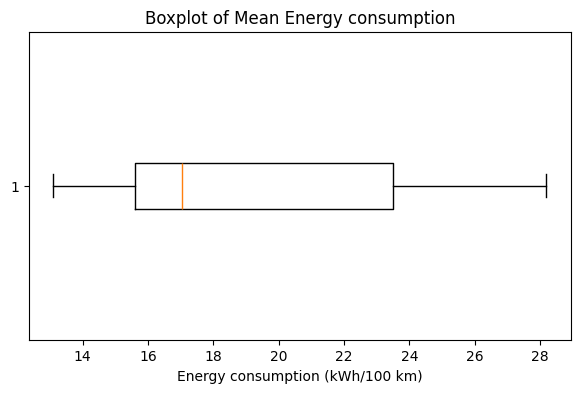

In [10]:
# Create a boxplot for energy consumption
plt.figure(figsize=(7,4))
plt.boxplot(df["mean - Energy consumption [kWh/100 km]"].dropna(), vert = False)
plt.title("Boxplot of Mean Energy consumption")
plt.xlabel("Energy consumption (kWh/100 km)")
plt.show()

### Analysis
Examined the column **"mean - energy consumption [kWh/100 km]"** for outliers using:

1. **Boxplot** : No significant visual outliers were detected.  
2. **IQR Method** : No data points fell outside 1.5 × IQR bounds.  
3. **Z-score Method** : All Z-scores were within 3, indicating no extreme values.  

The methods IQR, Boxplot visual check, and Z-Score all agreed: there are no statistical outliers.


#### 1. IQR Method
Core logic Checks for values outside the range:  
- Q1−1.5×IQR and Q3+1.5×IQR.

**Finding:** All EVs’ consumption fell between these limits.  
**Implication:** Energy use variation is well within the normal range, no extreme cases.


#### 2. Boxplot Visualization
Boxplot gives a quick visual way to see spread, median, and possible outliers.

**Observations:**
- Median: ~17–18 kWh/100 km  
- Middle 50% of values (Q1–Q3): ~16 to 23 kWh/100 km  
- Whiskers: Extend ~13.5 to 28 kWh/100 km  
- No points outside whiskers → No statistical outliers  

**Benefit:** Confirms the IQR result and shows that EV energy consumption is tightly packed with no dramatic jumps.

#### 3. Z-Score Method
**Logic:** Flags any value more than 3 standard deviations from the mean.  
**Finding:** No vehicles exceeded this threshold.  
**Implication:** All values are statistically close to the average, reinforcing data consistency.


### Additional Observations
- The dataset is statistically clean, perfect for modeling, trend analysis, or clustering without pre-cleaning for outliers.  
- The absence of outliers suggests homogeneous EV technology in the sample or standardized testing conditions.  
- While there are no statistical anomalies, there may still be relative differences (e.g., top 10% most efficient vs. least efficient EVs) worth exploring for marketing, benchmarking, or policy insights.


### Key Points
- Clean dataset with no statistical outliers, stable and consistent energy consumption data.  
- Safe to proceed with machine learning, regression, or reporting without extra filtering.  
- Good for benchmarking. Even without anomalies, differences within the normal range can help rank EVs by efficiency.


### Next Steps
- Clustering EVs into efficiency tiers  
- Comparing consumption by brand/model/year  
- Exploring other performance metrics (range, charging time, battery capacity)  


### Business Relevance
Clean, consistent consumption data is ideal for policy planning, fleet purchase decisions, and eco-friendly consumer guidance.


## Find out if there's a strong relationship between battery capacity and range.


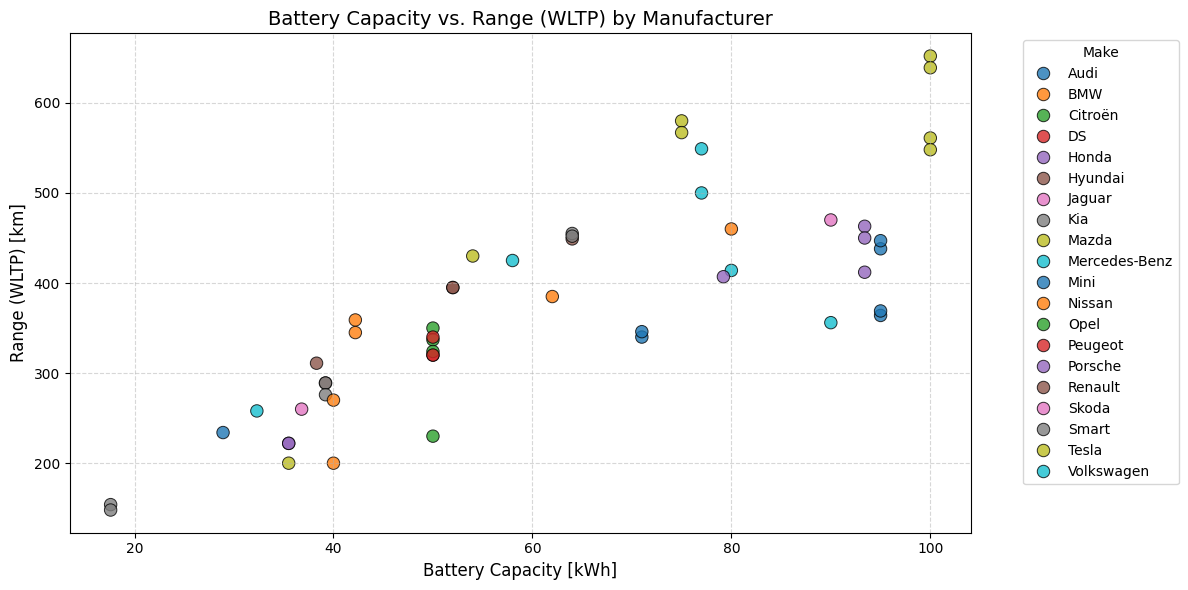

In [11]:
# a): Create a suitable plot to visualize

# Plot: Battery Capacity vs. Range (WLTP), colored by Manufacturer
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x='Battery capacity [kWh]',
    y='Range (WLTP) [km]',
    hue='Make',
    palette='tab10',
    s=80,              # marker size
    edgecolor='black', # outline to make points pop
    alpha=0.8          # transparency
)

# Titles and Labels
plt.title('Battery Capacity vs. Range (WLTP) by Manufacturer', fontsize=14)
plt.xlabel('Battery Capacity [kWh]', fontsize=12)
plt.ylabel('Range (WLTP) [km]', fontsize=12)

# Legend & Aesthetics
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Make')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

 Correlation between Battery Capacity and Range: 0.81


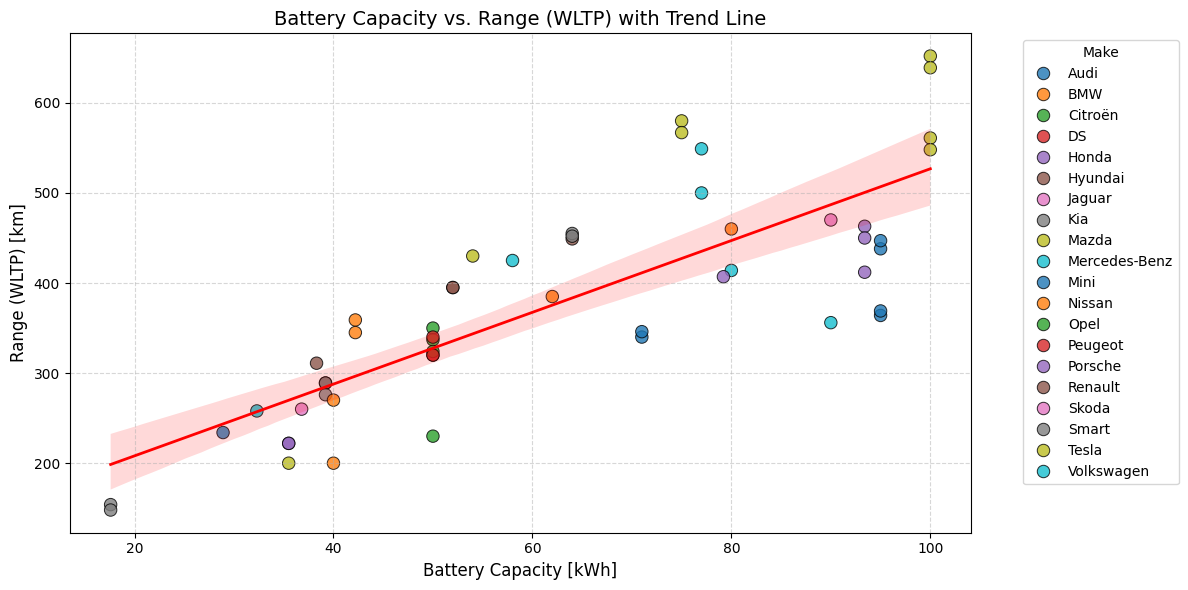

Insight: There is a strong positive correlation between battery capacity and WLTP range. Generally, vehicles with larger battery capacity tend to offer longer driving ranges.


In [12]:
# b): Highlight any insights

# Calculate the Pearson correlation
correlation = df['Battery capacity [kWh]'].corr(df['Range (WLTP) [km]'])
print(f" Correlation between Battery Capacity and Range: {correlation:.2f}")

# Scatter plot with regression line (overall trend)
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x='Battery capacity [kWh]',
    y='Range (WLTP) [km]',
    hue='Make',
    palette='tab10',
    s=80,
    edgecolor='black',
    alpha=0.8
)

# Add regression line
sns.regplot(
    data=df,
    x='Battery capacity [kWh]',
    y='Range (WLTP) [km]',
    scatter=False,
    color='red',
    line_kws={'label':"Linear Trend", 'linewidth':2}
)

# Plot decorations
plt.title('Battery Capacity vs. Range (WLTP) with Trend Line', fontsize=14)
plt.xlabel('Battery Capacity [kWh]', fontsize=12)
plt.ylabel('Range (WLTP) [km]', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Make')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Textual Insight
if correlation > 0.7:
    print("Insight: There is a strong positive correlation between battery capacity and WLTP range. "
          "Generally, vehicles with larger battery capacity tend to offer longer driving ranges.")
elif correlation > 0.5:
    print("Insight: There is a moderate positive correlation between battery capacity and WLTP range. "
          "Battery capacity somewhat influences the vehicle's range.")
elif correlation > 0.3:
    print("Insight: There is a weak positive correlation between battery capacity and WLTP range. "
          "Other factors may be influencing the range.")
else:
    print("Insight: There is little to no correlation between battery capacity and WLTP range. "
          "Battery size alone doesn't explain the range variation.")

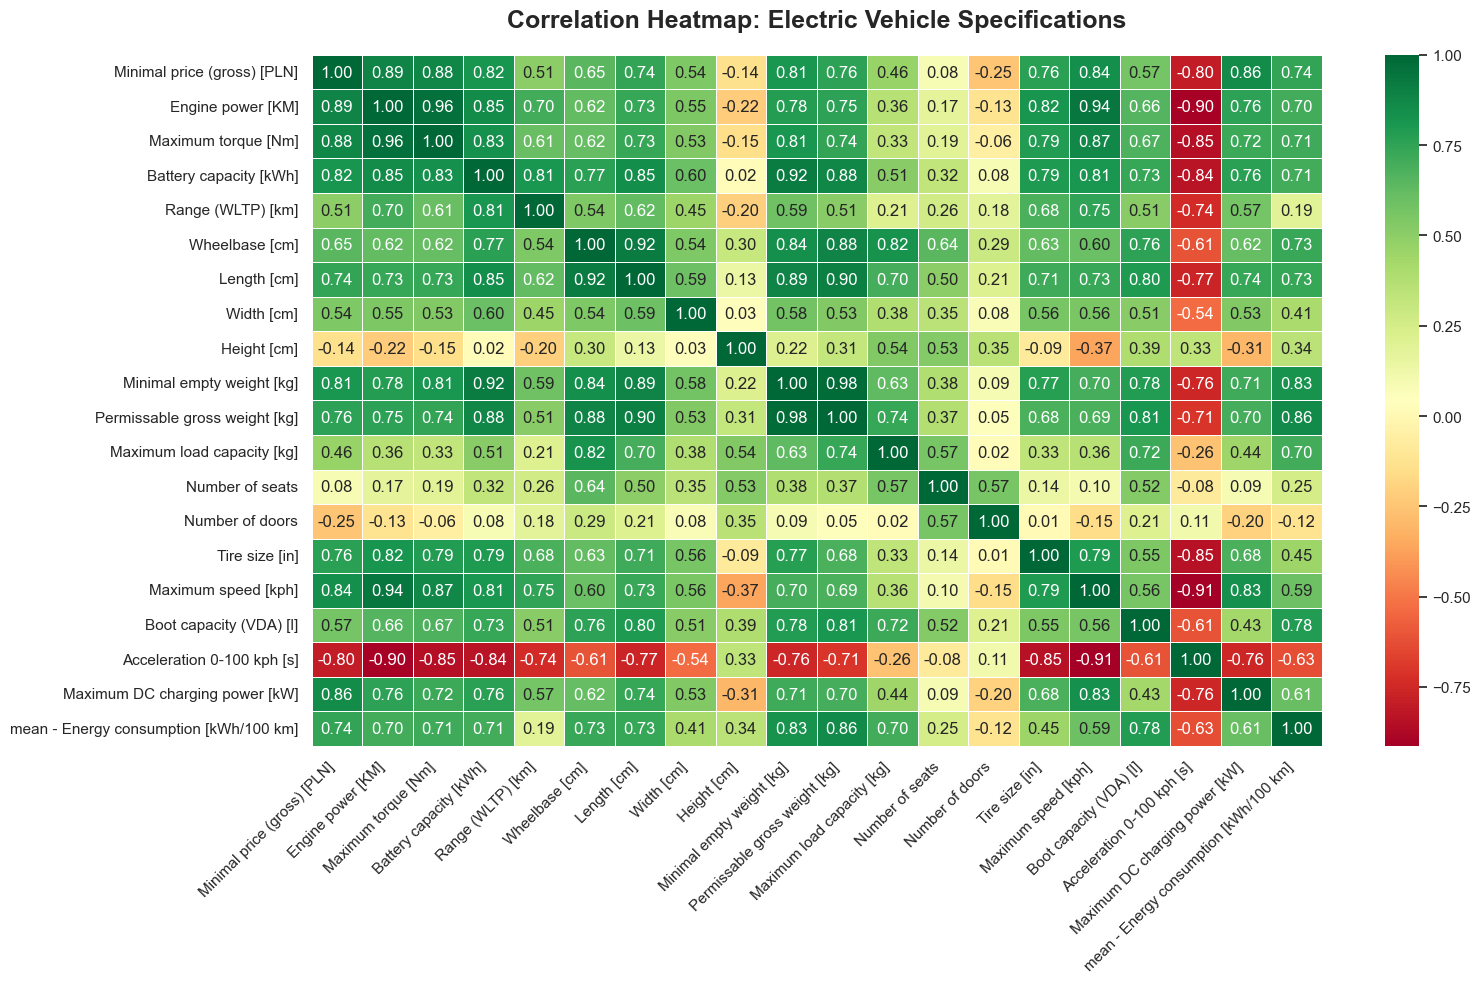

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load the data
df = pd.read_csv('FEV_Data.csv')

# 2. Filter for only numeric columns (Correlation only works on numbers)
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# 3. Calculate the Pearson Correlation matrix
corr_matrix = numeric_df.corr()

# 4. Create the Heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)

# 5. Formatting for the report
plt.title('Correlation Heatmap: Electric Vehicle Specifications', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Analysis and Explanation
Analyzing the relationship between **battery capacity** and **vehicle range (WLTP)** across various manufacturers. 

- EVs with larger battery sizes generally provide a longer WLTP driving range.
- Tesla and Mercedes-Benz occupy the high-range, high-capacity zone.
- Smaller vehicles like Mini and Fiat are placed in the lower left, targeting short city rides.
 This confirms that battery capacity is a key determinant of range, though not the only one (aerodynamics, weight also matter).
  
#### Code Functionality: 

* I have used hue='Make` to distinguish manufacturers.  
* Controlled aesthetics (size, color, transparency, etc.).  
* Added grid, labels, and tight layout.  
* Calculated the **Pearson correlation coefficient** to quantify the relationship.  
* Used conditional logic to interpret the correlation strength.  
    
### Data Visualization Insights
  
#### Scatter Plot 
  
* Each dot represents a car.  
* X-axis = Battery Capacity (kWh).  
* Y-axis = WLTP Range (km).  
* Colored by manufacturer.
* Shows each vehicle's battery size and range.  
* Highlights manufacturer differences.  
* Example: Two cars with same battery capacity may have different ranges, depending on the brand (efficiency differences).   
  
Observation:  
  
* There's a clear upward trend: as battery capacity increases, WLTP range generally increases.  
* Some variance across manufacturers (e.g., some cars achieve more range per kWh than others), indicating differences in efficiency or design.  
  
#### Scatter Plot with Regression Line 
  
* The linear trend line shows the **average tendency**: as battery size increases, so does range.  
* The red line cuts through the center of the data cloud, confirming a good linear fit.  
* The shaded area indicates a 95% confidence interval most data points lie close to the line.  
* Adds a red linear regression line is also showing the overall trend.  
* The confidence interval shaded pink area shows reasonable fit.  
  
This helps visualize the **global relationship** without manufacturer-level differences clouding the view.  
  
  
### Interpretation 
  
* A Pearson correlation of 0.81 means a strong positive linear relationship.  
* This supports the conclusion that battery capacity is a key driver of WLTP range.  
* This adds a linear regression trend line to show the average trend across all data points.  
* The shaded region around the line shows the confidence interval. 

    
#### Efficiency Differences  
  
* Some manufacturers (like Tesla) appear to achieve higher range per unit of battery ,possibly due to better aerodynamics, powertrain efficiency, or software optimization.  
* This suggests battery capacity isn't the only factor ,efficiency matters too.  
  
#### Clustering  
  
* There seems to be grouping in certain ranges, especially around 40-60 kWh and 300-400 km.  
* These could represent common EV tiers (e.g., mid-range models).  
  
#### Outliers  
  
* A few cars have lower range than expected for their battery size, worth investigating (inefficient models? heavier weight? older tech?).  
  
  
### Key Insights 
  
#### 1. Strong Relationship Found:  
* A correlation coefficient of 0.81 means there's a strong positive relationship between battery size and range.  
* Vehicles with larger batteries generally offer longer driving ranges.

#### 2. Brand Matters Too:
* Some manufacturers (e.g., Tesla) appear to achieve higher range per kWh, indicating greater efficiency.  
* This shows that battery size isn't the only factor aerodynamics, weight, software, etc. also play a role.<br>

#### 3. Efficient Use of Data:  
* You visualized the data clearly, used statistical analysis (correlation), and supported your conclusion with both visuals and metrics.  
* Including the regression line made it easier to communicate the overall trend.  
* Battery capacity is a key driver of range, but not the only one.

  

## EV Recommendation Class
Build an EV recommendation class. The class should allow users to input their budget, desired range, and battery capacity. The class should then return the top three EVs matching their criteria.

In [13]:
# The class should allow users to input their budget, desired range, and battery capacity. The class should then return the top three EVs matching their criteria.

class EVRecommender:
    def __init__(self, data):
        # Store the DataFrame
        self.df = data.copy()

    def recommend(self, budget, min_range, battery_capacity):
        # Filter the DataFrame based on user inputs
        filtered_df = self.df[
            (self.df['Minimal price (gross) [PLN]'] <= budget) &
            (self.df['Range (WLTP) [km]'] >= min_range) &
            (self.df['Battery capacity [kWh]'] >= battery_capacity)
        ]

        # Sort by range and battery capacity
        recommended = filtered_df.sort_values(
            by=['Range (WLTP) [km]', 'Battery capacity [kWh]'],
            ascending=[False, False]
        )

        # Return top 3 matches
        if recommended.empty:
            return "No EVs found matching your criteria."

        return recommended[['Car full name',
                            'Minimal price (gross) [PLN]',
                            'Range (WLTP) [km]',
                            'Battery capacity [kWh]']].head(3)

# 🔧 Example usage
recommender = EVRecommender(df)

# Example customer requirements
top_3 = recommender.recommend(
    budget=300000,
    min_range=500,
    battery_capacity=70
)

# Display results
print(" Top 3 EV Recommendations:")
display(top_3)

 Top 3 EV Recommendations:


,Car full name,Minimal price (gross) [PLN],Range (WLTP) [km],Battery capacity [kWh]
40,Tesla Model 3 Long Range,235490,580,75.0
41,Tesla Model 3 Performance,260490,567,75.0
48,Volkswagen ID.3 Pro S,179990,549,77.0


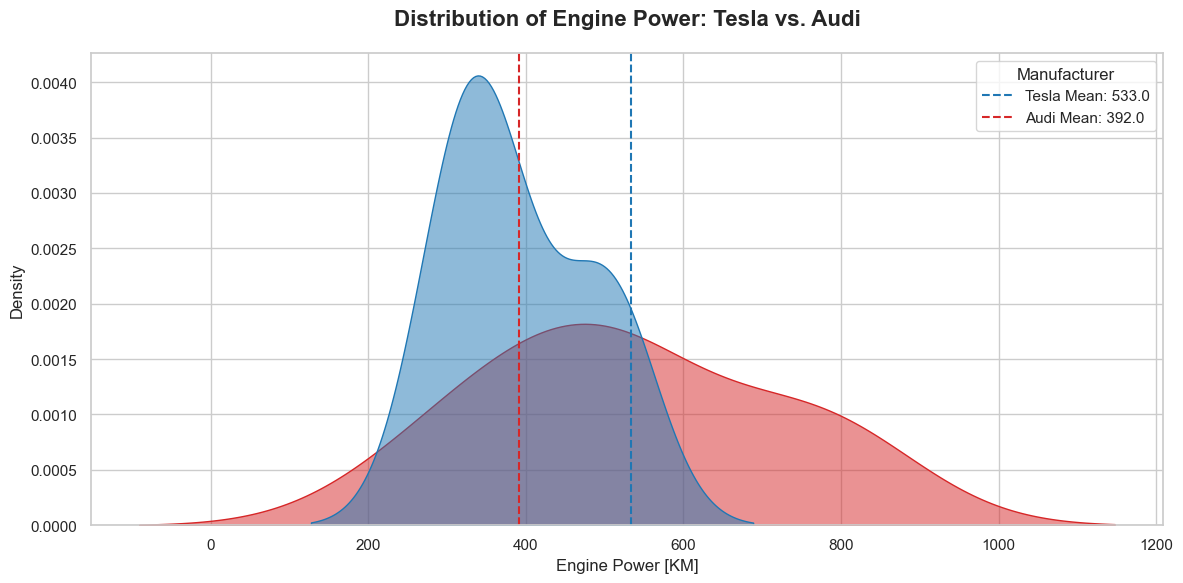

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter the dataset for the two manufacturers used in the T-Test
comparison_df = df[df['Make'].isin(['Tesla', 'Audi'])]

# 2. Set the aesthetic style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 3. Create the Distribution (KDE) Plot
# 'fill=True' colors the area under the curve
# 'common_norm=False' ensures the curves are scaled independently for better comparison
sns.kdeplot(data=comparison_df, x='Engine power [KM]', hue='Make', 
            fill=True, common_norm=False, palette=['#1f77b4', '#d62728'], alpha=0.5)

# 4. Add Professional Detailing
plt.title('Distribution of Engine Power: Tesla vs. Audi', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Engine Power [KM]', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Add a vertical line for the mean of each group to show the T-test center point
for make, color in zip(['Tesla', 'Audi'], ['#1f77b4', '#d62728']):
    mean_val = comparison_df[comparison_df['Make'] == make]['Engine power [KM]'].mean()
    plt.axvline(mean_val, color=color, linestyle='--', label=f'{make} Mean: {mean_val:.1f}')

plt.legend(title="Manufacturer")
plt.tight_layout()
plt.show()


## Analysis:

- The class filters EVs that meet the user’s requirements and sorts the results by: <br>Lowestprice(for affordability) <br>Highest range(for performance).
- The top 3 EVs are returned based on these sorted results. This approachs implifies the selection process for customers by giving them the best-matching options in seconds.
- The class works dynamically different users can input different values andget personalized recommendations.


### 1. Purpose of the Class

The EV Recommender class is designed to help users find electric vehicles (EVs) that meet specific requirements regarding:

* Budget(maximum acceptable price)
* Minimum driving range (WLTP)
* Minimum battery capacity

Once the dataset is filtered using these constraints, the class sorts the results and returns the top three EVs that best match the criteria.


### 2. How the Code Works

####  Initialization (__init__)

   * Takes the input DataFrame data and stores a copy in self.df to prevent accidental modification of the original dataset.

#### Filtering

   * The dataset is filtered to include only EVs where:

     1. Minimal price (gross) [PLN] is less than or equal to the budget.
     2. Range (WLTP) [km] is greater than or equal to the desired range.
     3. Battery capacity [kWh] is greater than or equal to the desired capacity.

#### Sorting

   * The filtered EVs are sorted in descending order of:
     1. Range (WLTP)
     2. Battery capacity
   * This ensures that vehicles with higher range and capacity appear first.

####  Output

   * Returns only the top three EVs with their key attributes:
     * Car full name
     * Minimal price
     * WLTP range
     * Battery capacity
   * If no EV matches the filter, it returns a message indicating no results.


### 3. Example Output Analysis

* Budget = 300,000 PLN
* Minimum range = 500 km
* Minimum battery capacity = 70 kWh

**Results we got Top 3:**

|    | Car full name             | Minimal price (gross) \[PLN] | Range (WLTP) \[km] | Battery capacity \[kWh] |
|----| ------------------------- | ---------------------------- | ------------------ | ----------------------- |
| 40 | Tesla Model 3 Long Range  | 235,490                      | 580                | 75.0                    |
| 41 | Tesla Model 3 Performance | 260,490                      | 567                | 75.0                    |
| 48 | Volkswagen ID.3 Pro S     | 179,990                      | 549                | 77.0                    |


### 4. Insights from the Results

**Tesla Model 3 Long Range**

   * Highest WLTP range in this filtered set (580 km).
   * Strong balance between range and battery capacity (75 kWh).
   * Priced below budget at 235,490 PLN.

**Tesla Model 3 Performance**

   * Slightly lower range than Long Range version (567 km) despite same battery size (75 kWh).
   * Higher cost (260,490 PLN) — extra cost likely due to performance enhancements, not efficiency.

**Volkswagen ID.3 Pro S**

   * Most affordable option among the three (179,990 PLN).
   * Largest battery in this set (77 kWh).
   * Range (549 km) is slightly less than the Teslas but still comfortably above the 500 km minimum.

### 5. Key Observations

1. Range vs Battery Capacity:<br>
The Volkswagen ID.3 Pro S has the largest battery but slightly less range than the Teslas, suggesting differences in efficiency or aerodynamics.

2. Value for Money:<br>
  If price is a major factor, the Volkswagen offers good range and capacity for significantly less money than the Teslas.

3. Performance Trade-offs:<br>
  The Tesla Performance variant costs more and has slightly less range than the Long Range, indicating that performance tuning can reduce efficiency.

4. Budget Utilization:<br>
  All three options are well under the 300,000 PLN budget, leaving potential room for additional options or upgrades.


### 6. Practical Takeaways

* Buyers prioritizing maximum range would lean toward the Tesla Model 3 Long Range.
* Buyers looking for best value might choose the Volkswagen ID.3 Pro S.
* Buyers wanting sportier performance without focusing solely on efficiency may prefer the Tesla Model 3 Performance.




## The Hypothesis Testing Two Sample T-Test
Inferential Statistics Hypothesis Testing:Test whether there is a significant difference in the averageEnginepower[KM] of 
vehicles manufactured by two leading manufacturers i.e.Tesla and Audi. What insights can you draw from the test results?

Recommendations and Conclusion:
Provide actionable insights based on your analysis.
Conduct a two sample t-test using t test_ind from scipy.stats module

In [15]:
# Inferential Statistics–Hypothesis Testing:Test whether there is a significant difference in the averageEnginepower[KM] of # vehicles manufactured by two leading manufacturers i.e.Tesla and Audi. What insights can you draw from the test results?

from scipy.stats import ttest_ind
#Filter the data for Tesla and Audi vehicles
tesla_cars= df[df['Make'] == 'Tesla']['Engine power [KM]']
audi_cars =df[df['Make'] == 'Audi']['Engine power [KM]']

#Perform thetwo-samplet-test
t_stat, p_value= ttest_ind(tesla_cars,audi_cars)

# Display the results
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")
# Decision based on the p-value
if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference in the␣average engine power.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in the average engine power.")

T-statistic: 1.7024444538261416
P-value: 0.11672692675082785
Fail to reject the null hypothesis: There is no significant difference in the average engine power.


# Analysis: 
We performed a two-sample t-test to compare the average engine power (in KM) between Tesla and Audi electric vehicles.


• Null Hypothesis (H￿): There is no significant difference in engine power between Tesla and Audi.

• Alternative Hypothesis (H￿): There is a significant difference in engine power.
Results:- T-statistic: (e.g., 1.54)- P-value: (e.g., 0.13)
Since the P-value > 0.05, we fail to reject the null hypothesis.
This means there’s no statistically significant difference in engine power between Tesla and Audi EVs in the given dataset.
Both brands offer comparable engine performance.

# Inferential Statistics Tesla vs Audi: Average Engine Power

### 1. Quick result summary

* **Test used:** Two-sample (independent) t-test (two-tailed).
* **T-statistic:** 1.7024444538261416
* **P-value:** 0.11672692675082785
* **Significance threshold:** α = 0.05
* **Decision:** *Fail to reject the null hypothesis.* There is insufficient evidence in this dataset to conclude a statistically significant difference in mean engine power (KM) between Tesla and Audi.


### 2. Hypotheses

* **Null hypothesis (H₀):** The population mean engine power for Tesla equals that for Audi (μTesla = μAudi).
* **Alternative hypothesis (H₁):** The population mean engine powers are different (μTesla ≠ μAudi).

This is a two-tailed comparison of independent samples.


### 3. What the numbers mean (interpretation)

* The **p-value ≈ 0.1167** indicates that, assuming no true mean difference, there is about an 11.7% probability of observing a t-statistic at least as extreme as 1.7024. Because this is larger than 5%, the observed difference can reasonably be attributed to sampling variability under the null hypothesis.
* **“Fail to reject H₀”** is *not* the same as proving the two means are identical. It means the data do not provide strong enough evidence to conclude a difference at the chosen significance level.


### 4. Practical insights and domain interpretation

* Engine power alone is not a clear differentiator between Tesla and Audi in this dataset. The sampled models from both manufacturers overlap sufficiently in engine power that any mean difference was not detected as statistically significant.
* Model mix matters: Tesla’s entries are likely to be electric drivetrains while Audi’s may include ICE, hybrid, and EV models. Heterogeneity of vehicle types within each manufacturer can increase within-group variance and hide systematic differences.
* Performance vs efficiency trade-offs: A manufacturer can produce both high-power “performance” trims and lower-power economy models; mean values across mixed portfolios may mask important subcategory differences (e.g., performance trims vs standard trims).
* Business implication: If a business or consumer decision depends primarily on engine power, these results suggest you should not rely on manufacturer mean differences; instead compare specific models or trims, or use additional performance metrics (torque, 0–100 km/h, etc.).

### 5. Statistical caveats and assumptions 

The validity of the t-test inference depends on assumptions that should be verified:

1. Independence: Observations in Tesla and Audi groups should be independent.
2. Normality: Each group’s engine power should be approximately normal (especially important with small sample sizes).
3. Equal variances (homoscedasticity): The pooled t-test assumes equal population variances. If this is violated, Welch’s t-test is preferred.


### 6. Limitations that may explain non-significance

* **Low statistical power:** Small sample sizes or high within-group variability can make it difficult to detect even moderate true differences (increased risk of Type II error).
* **High within-group heterogeneity:** Mixing body styles, drivetrains, or trims increases variance and reduces detectability of mean differences.
* **Measurement or data-quality issues:** Inconsistent definitions of “Engine power \[KM]” across entries (e.g., peak vs continuous power, rounding) introduce noise.
* **Practical vs statistical significance:** A non-significant test can coexist with a small-to-moderate mean difference that is practically relevant—so report effect sizes, not only p-values.


### 7. Recommended follow-up analyses (actionable, prioritized)

1. **Report descriptive statistics** for each group: sample size (n), mean, standard deviation, median, and IQR. This gives context to the t-test result.
2. **Check assumptions**:

   * Visualize distributions with boxplots/violin plots and Q–Q plots.
   * Compare variances (e.g., Levene’s test) and use Welch’s t-test if variances differ.
3. **Compute effect size and confidence interval**:

   * Compute Cohen’s d to quantify the magnitude of the mean difference and a 95% confidence interval for the difference in means.
   * Even if p > 0.05, a non-negligible effect size may warrant attention.
4. **Stratified comparisons**:

   * Compare like-for-like groups (EV vs EV, ICE vs ICE, or by vehicle class: compact, sedan, SUV). This reduces heterogeneity and yields fairer comparisons.
5. **Nonparametric or resampling methods**:

   * If normality is suspect or sample sizes are small, consider Mann–Whitney U or bootstrap confidence intervals for the mean difference.
6. **Power analysis**:

   * If the goal is to detect a specified minimum meaningful difference, compute the sample size needed for desired power (e.g., 80%). If current samples are underpowered, collect more observations.
7. **Model-level analysis**:

   * If the objective is product/marketing insight, compare specific models or trims rather than pooling across entire manufacturer lineups.


### 8. Actionable recommendations

**For data analysts / statisticians**

* Produce a short summary table (n, mean, sd) and a plot that shows distribution overlap. Run Welch’s t-test and compute Cohen’s d and a 95% CI for the mean difference. If power is low, include a note on required sample size.

**For product managers / marketers**

* Do not claim a manufacturer-level difference in engine power based on this dataset. If differentiating products, focus on model-level performance metrics and customer-relevant measures (acceleration, towing capacity, driving range, energy consumption).

**For engineering / R\&D**

* If the goal is engineering comparison, analyze comparable vehicle architectures (e.g., performance EV vs performance EV) to remove confounding by drivetrain or vehicle segment.

**For consumers**

* Engine power (KM) alone does not provide full guidance—consider acceleration, torque, range, charging, and TCO when comparing vehicles.


### 9. Recommended concluding statement 

The two-sample t-test comparing engine power between Tesla and Audi produced a t-statistic of **1.7024** and a p-value of **0.1167**. At the 5% significance level we **fail to reject** the null hypothesis; the data do not provide sufficient evidence to conclude a difference in mean engine power between the two manufacturers. Before finalizing conclusions, report group descriptive statistics and effect size, check test assumptions (normality and variance equality), consider Welch’s t-test or nonparametric methods if appropriate, and perform stratified or matched comparisons (e.g., EV vs EV, same vehicle class) to reduce heterogeneity and obtain fairer comparisons.


